In [1]:
import matplotlib.pyplot as plt
from seaborn import heatmap
from seaborn import pairplot
from besos import sampling
import pandas as pd
plt.rcParams.update({'font.size': 15})

# BESOS ToolBox For Buildings Surrogate Design Optimization

BESOS integrates building simulation, surrogate modelling for desing exploration and optimization.

It enables:

+ EnergyPlus model editing and execution via EPPy 
+ Evaluation of Parameter Space and Objectives in a specific Weather Location
+ Samples Generation using the [sampling toolboxes](https://pythonhosted.org/pyDOE/)
+ Surrogate model creation with machine learning toolboxes like [ScikitLearn](https://scikit-learn.org/stable/) and [TensorFlow](https://www.tensorflow.org/)
+ Model Exploration And Optimization

The `besos` module simplifies the interconnection of the above items.

![Image](image/flow_diagram.PNG)

# Besos Tutorial Analysis
This notebook performs a parametric analysis of a building design using EnergyPlus and BESOS helper functions.  
We load a model from **test.idf**, define parameters to vary, set objectives,then run the model for a signle parameter and finaly all parameter combinations and plot the results.

## Read and explore the EnergyPlus model

The building is defined by the Information Data File (`.idf`) or using the new EnergyPlus format (`epJSON`).


In order to modify it programatically, we load it as a Python object using wrappers for EEPy.

If you are using the newer JSON format, then any JSON parsing library will work.

In [2]:
from besos import eppy_funcs as ef

In [3]:
#Besos Uses eppy_function to manage the idf files
building = ef.get_building('test.idf')

Relative to World Coordinates:   0%|          | 0/4 [00:00<?, ?it/s]

(<Figure size 432x288 with 1 Axes>,
 <matplotlib.axes._subplots.Axes3DSubplot at 0x7fbab471cd60>)

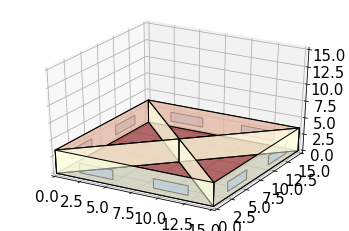

In [4]:
building.view_model()

In [5]:
building

In [6]:
building.idfobjects

{'VERSION': [
 Version,
     9.6;                      !- Version Identifier
 ],
 'SIMULATIONCONTROL': [
 SimulationControl,
     Yes,                      !- Do Zone Sizing Calculation
     Yes,                      !- Do System Sizing Calculation
     No,                       !- Do Plant Sizing Calculation
     No,                       !- Run Simulation for Sizing Periods
     Yes,                      !- Run Simulation for Weather File Run Periods
     No,                       !- Do HVAC Sizing Simulation for Sizing Periods
     1;                        !- Maximum Number of HVAC Sizing Simulation Passes
 ],
 'PERFORMANCEPRECISIONTRADEOFFS': [],
 'BUILDING': [
 Building,
     Building,                 !- Name
     0,                        !- North Axis
     Suburbs,                  !- Terrain
     0.04,                     !- Loads Convergence Tolerance Value
     0.4,                      !- Temperature Convergence Tolerance Value
     FullExterior,             !- Solar Distri

In [7]:
for class_name,idfobject in building.idfobjects.items():
    if len(idfobject)>0:
        print(class_name)

VERSION
SIMULATIONCONTROL
BUILDING
SHADOWCALCULATION
SURFACECONVECTIONALGORITHM:INSIDE
SURFACECONVECTIONALGORITHM:OUTSIDE
HEATBALANCEALGORITHM
ZONECAPACITANCEMULTIPLIER:RESEARCHSPECIAL
TIMESTEP
CONVERGENCELIMITS
SITE:LOCATION
SIZINGPERIOD:DESIGNDAY
RUNPERIOD
RUNPERIODCONTROL:DAYLIGHTSAVINGTIME
SITE:GROUNDTEMPERATURE:BUILDINGSURFACE
SITE:GROUNDTEMPERATURE:FCFACTORMETHOD
SITE:GROUNDTEMPERATURE:SHALLOW
SITE:GROUNDTEMPERATURE:DEEP
SITE:GROUNDREFLECTANCE
SITE:GROUNDREFLECTANCE:SNOWMODIFIER
SCHEDULETYPELIMITS
SCHEDULE:DAY:HOURLY
SCHEDULE:WEEK:DAILY
SCHEDULE:YEAR
SCHEDULE:COMPACT
MATERIAL
MATERIAL:NOMASS
MATERIAL:INFRAREDTRANSPARENT
WINDOWMATERIAL:GLAZING
WINDOWMATERIAL:GAS
CONSTRUCTION
GLOBALGEOMETRYRULES
ZONE
BUILDINGSURFACE:DETAILED
FENESTRATIONSURFACE:DETAILED
WINDOWPROPERTY:FRAMEANDDIVIDER
PEOPLE
LIGHTS
OTHEREQUIPMENT
OUTPUTCONTROL:ILLUMINANCEMAP:STYLE
ZONEINFILTRATION:DESIGNFLOWRATE
DESIGNSPECIFICATION:OUTDOORAIR
DESIGNSPECIFICATION:ZONEAIRDISTRIBUTION
SIZING:PARAMETERS
SIZING:ZONE
ZONE

Let's check what `MATERIAL` are in the model.  


In [8]:
building.idfobjects["MATERIAL"]

[
Material,
    Urea Formaldehyde Foam_00171,    !- Name
    Rough,                    !- Roughness
    0.0171,                   !- Thickness
    0.04,                     !- Conductivity
    10,                       !- Density
    1400,                     !- Specific Heat
    0.9,                      !- Thermal Absorptance
    0.6,                      !- Solar Absorptance
    0.6;                      !- Visible Absorptance
, 
Material,
    Cast Concrete_01,         !- Name
    Rough,                    !- Roughness
    0.1,                      !- Thickness
    1.13,                     !- Conductivity
    2000,                     !- Density
    1000,                     !- Specific Heat
    0.9,                      !- Thermal Absorptance
    0.6,                      !- Solar Absorptance
    0.6;                      !- Visible Absorptance
, 
Material,
    Floor/Roof Screed_007,    !- Name
    Rough,                    !- Roughness
    0.07,                     !- Thickness
 

In [9]:
for materials in building.idfobjects["MATERIAL"]:
     print("{} - {}[m]".format(materials.Name,materials.Thickness))

Urea Formaldehyde Foam_00171 - 0.0171[m]
Cast Concrete_01 - 0.1[m]
Floor/Roof Screed_007 - 0.07[m]
Timber Flooring_003 - 0.03[m]
Asphalt 1_001 - 0.01[m]
MW Glass Wool (rolls)_00245 - 0.0245[m]
Plasterboard_0013 - 0.013[m]
Gypsum Plasterboard_0025 - 0.025[m]
Brickwork Outer_01 - 0.1[m]
XPS Extruded Polystyrene  - CO2 Blowing_0041 - 0.041[m]
Concrete Block (Medium)_01 - 0.1[m]
Gypsum Plastering_0013 - 0.013[m]


In [10]:
for fenestration in building.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
    print(fenestration)


FenestrationSurface:Detailed,
    Block1:ZoneWest_Wall_4_0_0_0_0_0_Win,    !- Name
    Window,                   !- Surface Type
    1001,                     !- Construction Name
    Block1:ZoneWest_Wall_4_0_0,    !- Building Surface Name
    ,                         !- Outside Boundary Condition Object
    AutoCalculate,            !- View Factor to Ground
    1,                        !- Frame and Divider Name
    1,                        !- Multiplier
    4,                        !- Number of Vertices
    -8.9122703919,            !- Vertex 1 Xcoordinate
    20.33207823,              !- Vertex 1 Ycoordinate
    0.84,                     !- Vertex 1 Zcoordinate
    -8.9122703919,            !- Vertex 2 Xcoordinate
    17.09660819,              !- Vertex 2 Ycoordinate
    0.84,                     !- Vertex 2 Zcoordinate
    -8.9122703919,            !- Vertex 3 Xcoordinate
    17.09660819,              !- Vertex 3 Ycoordinate
    2.26,                     !- Vertex 3 Zcoordinate

In [11]:
for construction in building.idfobjects['CONSTRUCTION']:
    print(construction)


Construction,
    LinearBridgingConstruction,    !- Name
    LinearBridgingLayer;      !- Outside Layer


Construction,
    IRTSurface,               !- Name
    IRTMaterial;              !- Outside Layer


Construction,
    Project ground floor,     !- Name
    Urea Formaldehyde Foam_00171,    !- Outside Layer
    Cast Concrete_01,         !- Layer 2
    Floor/Roof Screed_007,    !- Layer 3
    Timber Flooring_003;      !- Layer 4


Construction,
    Project ground floor_Rev,    !- Name
    Timber Flooring_003,      !- Outside Layer
    Floor/Roof Screed_007,    !- Layer 2
    Cast Concrete_01,         !- Layer 3
    Urea Formaldehyde Foam_00171;    !- Layer 4


Construction,
    Project flat roof,        !- Name
    Asphalt 1_001,            !- Outside Layer
    MW Glass Wool (rolls)_00245,    !- Layer 2
    3_RVAL_3,                 !- Layer 3
    Plasterboard_0013;        !- Layer 4


Construction,
    Project flat roof_Rev,    !- Name
    Plasterboard_0013,        !- Outside Laye

# Evaluators

`besos.evaluator` provides three different [Evaluators](https://besos.readthedocs.io/en/latest/modules/evaluator.html):
- the EnergyPlus Evaluator (`EvaluatorEP`)
- the Generic Evaluator (`EvaluatorGeneric`)
- the Energy Hub Evaluator (`EvaluatorEH`)



## EvaluatorGeneric
The `EvaluatorGeneric` takes a function with the correct number of inputs and produces outputs in the format `(objectives, constraints)` where objectives and constraints are tuples.

Since this evaluator only uses it's parameters to track the number of inputs and outputs (and their names), we can use numbered placeholders that are automatically generated by `Problem`

A `Problem` objects represent inputs and outputs.

In [12]:
from besos.evaluator import EvaluatorGeneric
from besos.problem import Problem

problem = Problem(
    1, 2, 0
)  # this denotes a problem which takes 1 input, produces 2 outputs and has no contraints

# These names are used on the headings of DataFrames generated by the problem and evaluators that use it
print(problem.names())



['inputs_0', 'outputs_0', 'outputs_1']


In [13]:
def function(values):  # define a dummy fucntion f1(x)=x, f2(x)=x^2
    return ((values[0], values[0] ** 2))

def function2(values):  # define a dummy fucntion f1(x)=x, f2(x)=x*2
    return ((values[0], values[0] * 2))

print("Functions values at 4 are:")

evaluator_1 = EvaluatorGeneric(function, problem)
evaluator_2 = EvaluatorGeneric(function2, problem)
print(evaluator_1([4]))
print(evaluator_2([4]))

Functions values at 4 are:
(4, 16)
(4, 8)


## EvaluatorEP



![Image](image/setting_up_the_evaluator.PNG)

Defines how we will evaluate the building;
- what external weather conditions is the building experiencing,
- what properties of the building will we be changing, and
- what are some of the performance metrics of the building that we want to explore.

The weather conditions are specified in the EnergyPlus Weather File (EWP) file. The properties we will change in the building will be defined in the parameter space. In the objectives we will specify the what output performance metrics we wish to extract such that we can explore them later.

In [14]:
from besos.evaluator import EvaluatorEP
from besos.problem import EPProblem



### What have we imported?
`EvaluatorEP` (EnergyPlus evaulator object) manages energy-plus simulations for a single problem. The evalutator needs a `EvaluatorEP` (`Parameters` to modify and `objectives` to report) and a `building` model.  
Problems, like `EPProblem` organise several parameters together.  

A problem (`problem = parameters + objectives`) can be easily applied to any building model (`evaluator = problem + building`).

Parameters, like `Parameter` describe a single variable for the building.
They are composed of a `Selector` and a `Descriptor`.





## Parameters and Objectives
A `problem` `Parameter` is composed with one `Selectors` that identify which part of the building model to modify, and a `Descriptors` that specify what kinds of values are valid for a parameter.

In [15]:

from besos.parameters import Parameter, FieldSelector, FilterSelector, GenericSelector


In [16]:
for materials in building.idfobjects["MATERIAL"]:
    print (materials)


Material,
    Urea Formaldehyde Foam_00171,    !- Name
    Rough,                    !- Roughness
    0.0171,                   !- Thickness
    0.04,                     !- Conductivity
    10,                       !- Density
    1400,                     !- Specific Heat
    0.9,                      !- Thermal Absorptance
    0.6,                      !- Solar Absorptance
    0.6;                      !- Visible Absorptance


Material,
    Cast Concrete_01,         !- Name
    Rough,                    !- Roughness
    0.1,                      !- Thickness
    1.13,                     !- Conductivity
    2000,                     !- Density
    1000,                     !- Specific Heat
    0.9,                      !- Thermal Absorptance
    0.6,                      !- Solar Absorptance
    0.6;                      !- Visible Absorptance


Material,
    Floor/Roof Screed_007,    !- Name
    Rough,                    !- Roughness
    0.07,                     !- Thickness
    

In [17]:
object_name='XPS Extruded Polystyrene  - CO2 Blowing_0041'
for materials in building.idfobjects["MATERIAL"]:
    if materials.Name == object_name:
        print (materials)


Material,
    XPS Extruded Polystyrene  - CO2 Blowing_0041,    !- Name
    Rough,                    !- Roughness
    0.041,                    !- Thickness
    0.034,                    !- Conductivity
    35,                       !- Density
    1400,                     !- Specific Heat
    0.9,                      !- Thermal Absorptance
    0.6,                      !- Solar Absorptance
    0.6;                      !- Visible Absorptance



## Field Selectors
`FieldSelector` object modify individual fields in a building model.  


The example building loaded here contains a `Material` class object named `XPS Extruded Polystyrene  - CO2 Blowing_0041` which has a `Thickness` field.  
We make a selector that modifies this insulation thickness.

In [18]:
insulation = FieldSelector(class_name='Material', object_name='XPS Extruded Polystyrene  - CO2 Blowing_0041', field_name='Thickness')

In [19]:
insulation

FieldSelector(field_name='Thickness', class_name='Material', object_name='XPS Extruded Polystyrene  - CO2 Blowing_0041')

### Setting all fields on objects of a certain class
If you have multiple objects of the same type that all share the same field to modify, you can modify them all with one selector by setting `object_name` to `'*'`.



In [20]:
[materials for materials in building.idfobjects["LIGHTS"]]# get a list of the Name property of all IDF objects of class MATERIAL


[
 Lights,
     Block1:ZoneWest,          !- Name
     Block1:ZoneWest,          !- Zone or ZoneList or Space or SpaceList Name
     Office_OpenOff_Light,     !- Schedule Name
     Watts/Area,               !- Design Level Calculation Method
     ,                         !- Lighting Level
     20,                       !- Watts per Zone Floor Area
     ,                         !- Watts per Person
     0,                        !- Return Air Fraction
     0.42,                     !- Fraction Radiant
     0.18,                     !- Fraction Visible
     1,                        !- Fraction Replaceable
     ;                         !- EndUse Subcategory,
 
 Lights,
     Block1:ZoneSouth,         !- Name
     Block1:ZoneSouth,         !- Zone or ZoneList or Space or SpaceList Name
     Office_OpenOff_Light,     !- Schedule Name
     Watts/Area,               !- Design Level Calculation Method
     ,                         !- Lighting Level
     20,                       !- Watts pe

Our building has several Lights, and all of the lights have a field called `Watts per Zone Floor Area`

In [21]:
lights_selector = FieldSelector(class_name='Lights', object_name='*', field_name='Watts per Zone Floor Area')

In [22]:
lights_selector

FieldSelector(field_name='Watts per Zone Floor Area', class_name='Lights', object_name='*')

In [23]:
# this selector affects the following objects
lights_selector.get_objects(building)

[
Lights,
    Block1:ZoneWest,          !- Name
    Block1:ZoneWest,          !- Zone or ZoneList or Space or SpaceList Name
    Office_OpenOff_Light,     !- Schedule Name
    Watts/Area,               !- Design Level Calculation Method
    ,                         !- Lighting Level
    20,                       !- Watts per Zone Floor Area
    ,                         !- Watts per Person
    0,                        !- Return Air Fraction
    0.42,                     !- Fraction Radiant
    0.18,                     !- Fraction Visible
    1,                        !- Fraction Replaceable
    ;                         !- EndUse Subcategory
, 
Lights,
    Block1:ZoneSouth,         !- Name
    Block1:ZoneSouth,         !- Zone or ZoneList or Space or SpaceList Name
    Office_OpenOff_Light,     !- Schedule Name
    Watts/Area,               !- Design Level Calculation Method
    ,                         !- Lighting Level
    20,                       !- Watts per Zone Floor Area
  

In [24]:
# setting sets all values at once, and getting retrieves the value of the field for each affected object.
lights_selector.set(building, 11)
lights_selector.get(building)

[11, 11, 11, 11]

In [25]:
[materials for materials in building.idfobjects["LIGHTS"]]# get a list of the Name property of all IDF objects of class MATERIAL


[
 Lights,
     Block1:ZoneWest,          !- Name
     Block1:ZoneWest,          !- Zone or ZoneList or Space or SpaceList Name
     Office_OpenOff_Light,     !- Schedule Name
     Watts/Area,               !- Design Level Calculation Method
     ,                         !- Lighting Level
     11,                       !- Watts per Zone Floor Area
     ,                         !- Watts per Person
     0,                        !- Return Air Fraction
     0.42,                     !- Fraction Radiant
     0.18,                     !- Fraction Visible
     1,                        !- Fraction Replaceable
     ;                         !- EndUse Subcategory,
 
 Lights,
     Block1:ZoneSouth,         !- Name
     Block1:ZoneSouth,         !- Zone or ZoneList or Space or SpaceList Name
     Office_OpenOff_Light,     !- Schedule Name
     Watts/Area,               !- Design Level Calculation Method
     ,                         !- Lighting Level
     11,                       !- Watts pe

### Runing a single value and single paramter problem

A single value `Parameter` object can be created specifing the `FieldSelector` object in the `selector=` field.

In [26]:
insulation = FieldSelector(class_name='Material', object_name='XPS Extruded Polystyrene  - CO2 Blowing_0041', field_name='Thickness')
parameters = [Parameter(selector=insulation,name='Insulation Thickness')] 
parameters

[Parameter(selector=FieldSelector(field_name='Thickness', class_name='Material', object_name='XPS Extruded Polystyrene  - CO2 Blowing_0041'), value_descriptors=[AnyValue()])]

Now we have to define the `objectives` and problem

In [27]:
objectives = ['Electricity:Facility','DistrictHeating:Facility','DistrictCooling:Facility'] # these get made into `MeterReader` or `VariableReader`
problem=EPProblem(parameters, objectives) # problem = parameters + objectives
problem

EPProblem(inputs=[Parameter(selector=FieldSelector(field_name='Thickness', class_name='Material', object_name='XPS Extruded Polystyrene  - CO2 Blowing_0041'), value_descriptors=[AnyValue()])], outputs=[MeterReader(class_name='Output:Meter', func=<function sum_values at 0x7fbab8c0c430>, key_name='Electricity:Facility'), MeterReader(class_name='Output:Meter', func=<function sum_values at 0x7fbab8c0c430>, key_name='DistrictHeating:Facility'), MeterReader(class_name='Output:Meter', func=<function sum_values at 0x7fbab8c0c430>, key_name='DistrictCooling:Facility')], minimize_outputs=[True, True, True], converters={'outputs': <class 'besos.objectives.MeterReader'>, 'constraints': <class 'besos.objectives.MeterReader'>})

In [28]:
evaluator = EvaluatorEP(problem, building, out_dir='outputdir', err_dir='outputdir' ,epw_file='ITA_Torino.160590_IWEC.epw') # evaluator = problem + building

/opt/conda/envs/myenv/lib/python3.9/site-packages/besos/evaluator.py:672: FutureWarning: epw_file has been deprecated and will be removed in the future. Use epw instead.
  warn(


Now we run the evaluator with wall insulation thickness set to 0.5m 

In [29]:
result = evaluator([0.5]) 
values = dict(zip(objectives, result))


EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.26 15:14


Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]


Initializing Response Factors
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT WALL"
Calculating CTFs for "PROJECT WALL"
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone and Enclosure Report Variables
Initializing Surface (Shading) Report Variables
Computing Interior Solar Absorption Factors
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior Diffuse Solar Absorption Factors
Initializing Solar Heat Gains
Initializing Internal Heat Gains
Initializing Interior Solar D

EnergyPlus Completed Successfully.


In [30]:
result1 = evaluator([1]) 
values1 = dict(zip(objectives, result1))

EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.26 15:14
Initializing Response Factors
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT WALL"
Calculating CTFs for "PROJECT WALL"
Calculating CTFs for "PROJECT WALL"
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone and Enclosure Report Variables
Initializing Surface (Shading) Report Variables
Computing Interior Solar Absorption Factors
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior Diffuse So

Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]


Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #2 SUMMER DESIGN DAY IN UNTITLED (01-01:31-12) AUG
Warming up
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #3 SUMMER DESIGN DAY IN UNTITLED (01-01:31-12) SEP
Warming up
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #4 WINTER DESIGN DAY IN UNTITLED (01-01:31-12)
Adjusting Air System Sizing
Adjusting Standard 62.1 Ventilation Sizing
Initializing Simulation
Reporting Surfaces
Beginning Primary Simulation
Initializing New Environment Parameters
Warming up {1}
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Starting Simulation at 01/01/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=01/21/2017
Continuing Simulation at 01/21/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=02/10/2017


EnergyPlus Completed Successfully.


In [31]:
values1 = dict(zip(objectives, result1))

In [32]:
for key, value in values.items():
    print(key, " :: ", "{0:.2f}".format(value/3.6e6), "kWh")

print()
print()

for key, value1 in values1.items():
    print(key, " :: ", "{0:.2f}".format(value1/3.6e6), "kWh")

Electricity:Facility  ::  17441.60 kWh
DistrictHeating:Facility  ::  11434.79 kWh
DistrictCooling:Facility  ::  13984.37 kWh


Electricity:Facility  ::  17441.60 kWh
DistrictHeating:Facility  ::  11270.08 kWh
DistrictCooling:Facility  ::  13956.52 kWh


# Giving more the one value to a Paramter with Descriptors

  
There are currently, two variants: `RangeParameter` and `CategoryParameter`.  


`RangeParameter` is a descriptor that indicates a parameter that can take on values from an interval.  
`CategoryParameter` is a descriptor that indicates a paramter that can take on values from a list.

In [33]:
from besos.parameters import RangeParameter,  CategoryParameter

### RangeParameters 
$min \leq x \leq max$

In [34]:
zero_to_one_exclusive = RangeParameter(min_val = 0.01, max_val=0.99)

### CategoryParameters 
A list of options.

In [35]:
text_example = CategoryParameter(options=['a', 'b', 'c', 'other'])
single_digit_integers = CategoryParameter(options=range(8,13))

In [36]:
zero_to_one_exclusive

RangeParameter(min=0.01, max=0.99)

We can combine this with the `Selector` above to get a `Parameter`:

In [37]:
insulation = FieldSelector(class_name='Material', object_name='XPS Extruded Polystyrene  - CO2 Blowing_0041', field_name='Thickness')

insulation_param = Parameter(selector=insulation,
                                 value_descriptor=zero_to_one_exclusive,
                                 name='Insulation Thickness')
print(insulation_param)
parameters = [insulation_param] 


Parameter(selector=FieldSelector(field_name='Thickness', class_name='Material', object_name='XPS Extruded Polystyrene  - CO2 Blowing_0041'), value_descriptors=[RangeParameter(min=0.01, max=0.99)])


/opt/conda/envs/myenv/lib/python3.9/site-packages/besos/parameters.py:424: FutureWarning: Use value_descriptors instead of value_descriptor.
  warnings.warn(


In [38]:
lights_param =     Parameter(
        lights_selector,
        value_descriptors=single_digit_integers ,
        name="Lights Watts/Area",
    )

In [39]:
lights_param

Parameter(selector=FieldSelector(field_name='Watts per Zone Floor Area', class_name='Lights', object_name='*'), value_descriptors=[CategoryParameter(options=[8, 9, 10, 11, 12])])

### Short-cuts for defining parameters

In [40]:
from besos.parameters import expand_plist


The `expand_plist` funcion can define `Parameters` more concisely. It takes a nested dictionary as input.
The keys in the first layer of this dictionary are the names of the idf objects.
These are associated with a dictionary that has keys matching the Fields of that object to modify.
Each field-key corresponds to a tuple containing the minimum and maximum values for that parameter.
The `class_name` is not specified.
Instead the model is searched for objects with the correct `object_name`.
**Note - doesn't like duplicate object names!**.

In [41]:
[materials for materials in building.idfobjects["WINDOWMATERIAL:GLAZING"]]

[
 WindowMaterial:Glazing,
     3,                        !- Name
     SpectralAverage,          !- Optical Data Type
     ,                         !- Window Glass Spectral Data Set Name
     0.006,                    !- Thickness
     0.775,                    !- Solar Transmittance at Normal Incidence
     0.071,                    !- Front Side Solar Reflectance at Normal Incidence
     0.071,                    !- Back Side Solar Reflectance at Normal Incidence
     0.881,                    !- Visible Transmittance at Normal Incidence
     0.08,                     !- Front Side Visible Reflectance at Normal Incidence
     0.08,                     !- Back Side Visible Reflectance at Normal Incidence
     0,                        !- Infrared Transmittance at Normal Incidence
     0.84,                     !- Front Side Infrared Hemispherical Emissivity
     0.84,                     !- Back Side Infrared Hemispherical Emissivity
     0.9,                      !- Conductivity
   

In [42]:
# class_name is NOT provided
#{'object_name':
# {'field_name':(min, max)}}
more_parameters = expand_plist(
    {
        #"Building":
        #{
        #    "North Axis":(0,359)
        #},
        "3":
         {
             'Conductivity':(0.1,1),
             'Solar Transmittance at Normal Incidence':(0.01,0.8)
         }
    })

In [43]:
for p in more_parameters:
    print(p)

Parameter(selector=FieldSelector(field_name='Conductivity', object_name='3'), value_descriptors=[RangeParameter(name='Conductivity', min=0.1, max=1)])
Parameter(selector=FieldSelector(field_name='Solar Transmittance at Normal Incidence', object_name='3'), value_descriptors=[RangeParameter(name='Solar Transmittance at Normal Incidence', min=0.01, max=0.8)])


### Parameter scripts using a Generic Selector

Parameters can also be created by defining a function that takes an idf and a value and mutates the idf. These functions can be specific to a certain idf's format, and can perform any arbitrary transformation. Creating these can be more involved.  
`eppy_funcs` contains the functions `one_window` and `wwr_all`. `one_window` removes windows from a building untill it has only one per wall. `wwr_all` takes a building with one window per wall and adjusts it to have a specific window to wall ratio.

BESOS also includes some pre-defined parameter scripts:
+ `wwr(Range)` for window to wall ratio  

Here we define the WWR of all walls in the model to be between 10% and 90%.


In [44]:
from besos.parameters import wwr

In [45]:
window_to_wall = wwr(RangeParameter(0.1,0.9)) # use a special shortcut to get the window-to-wall parameter

In [46]:
parameters = [insulation_param] + more_parameters +[window_to_wall] + [lights_param]

In [47]:
parameters

[Parameter(selector=FieldSelector(field_name='Thickness', class_name='Material', object_name='XPS Extruded Polystyrene  - CO2 Blowing_0041'), value_descriptors=[RangeParameter(min=0.01, max=0.99)]),
 Parameter(selector=FieldSelector(field_name='Conductivity', object_name='3'), value_descriptors=[RangeParameter(name='Conductivity', min=0.1, max=1)]),
 Parameter(selector=FieldSelector(field_name='Solar Transmittance at Normal Incidence', object_name='3'), value_descriptors=[RangeParameter(name='Solar Transmittance at Normal Incidence', min=0.01, max=0.8)]),
 Parameter(selector=wwrSelector(), value_descriptors=[RangeParameter(min=0.1, max=0.9)]),
 Parameter(selector=FieldSelector(field_name='Watts per Zone Floor Area', class_name='Lights', object_name='*'), value_descriptors=[CategoryParameter(options=[8, 9, 10, 11, 12])])]

In [48]:
problem=EPProblem(parameters, objectives)

## Sampling
One twe have created `Parameters` with `Selectors` and `Descriptors`.  
Then we can generate `Samples` with `besos.sampling`.

In [49]:
samples = sampling.dist_sampler(sampling.full_factorial, problem, num_samples=5, level=4)
samples

,Insulation Thickness,Conductivity,Solar Transmittance at Normal Incidence,"RangeParameter [0.1, 0.9]",Lights Watts/Area
0,0.010,0.100,0.0100,0.1,8
1,0.255,0.100,0.0100,0.1,8
2,0.500,0.100,0.0100,0.1,8
3,0.745,0.100,0.0100,0.1,8
4,0.010,0.325,0.0100,0.1,8
...,...,...,...,...,...
1019,0.745,0.550,0.6025,0.7,11
1020,0.010,0.775,0.6025,0.7,11
1021,0.255,0.775,0.6025,0.7,11
1022,0.500,0.775,0.6025,0.7,11


In [50]:
samples = sampling.dist_sampler(sampling.lhs, problem, num_samples=10)
samples

,Insulation Thickness,Conductivity,Solar Transmittance at Normal Incidence,"RangeParameter [0.1, 0.9]",Lights Watts/Area
0,0.062457,0.471147,0.587020,0.479515,12
1,0.119381,0.709870,0.070941,0.780367,8
2,0.942970,0.234600,0.660367,0.100888,9
3,0.702445,0.987983,0.469959,0.341502,11
4,0.618713,0.332772,0.292758,0.885550,10
5,0.876877,0.159363,0.782356,0.735171,9
6,0.380838,0.573887,0.350568,0.533584,11
7,0.547024,0.755674,0.499040,0.185081,12
8,0.219275,0.412856,0.092868,0.594607,10
9,0.426417,0.851932,0.218416,0.287281,8


In [51]:
problem

EPProblem(inputs=[Parameter(selector=FieldSelector(field_name='Thickness', class_name='Material', object_name='XPS Extruded Polystyrene  - CO2 Blowing_0041'), value_descriptors=[RangeParameter(min=0.01, max=0.99)]), Parameter(selector=FieldSelector(field_name='Conductivity', object_name='3'), value_descriptors=[RangeParameter(name='Conductivity', min=0.1, max=1)]), Parameter(selector=FieldSelector(field_name='Solar Transmittance at Normal Incidence', object_name='3'), value_descriptors=[RangeParameter(name='Solar Transmittance at Normal Incidence', min=0.01, max=0.8)]), Parameter(selector=wwrSelector(), value_descriptors=[RangeParameter(min=0.1, max=0.9)]), Parameter(selector=FieldSelector(field_name='Watts per Zone Floor Area', class_name='Lights', object_name='*'), value_descriptors=[CategoryParameter(options=[8, 9, 10, 11, 12])])], outputs=[MeterReader(class_name='Output:Meter', func=<function sum_values at 0x7fbab8c0c430>, key_name='Electricity:Facility'), MeterReader(class_name='O

## Evaluation
Now we can evaluate the samples. We create an energy plus evaluator (`EvaluatroEP`) using the parameters, and idf describing the building, and the objectives we want to measure. For this example we will just use one of the premade objectives: Electricity use for the whole facility.

In order to keep outputs we can flag keep_dirs, and once keep_dirs has been flagged, there will be a folder be created with a randomed name to store all the output files.
And there is an extra option called dest_folder to select which folder to store all the outputs folders or otherwise it will be saved to a folder call BESOS_Output as default.

In [52]:
objectives = ['Electricity:Facility','DistrictHeating:Facility','DistrictCooling:Facility'] # these get made into `MeterReader` or `VariableReader`

problem=EPProblem(parameters, objectives) # problem = parameters + objectives



In [ ]:
evaluator = EvaluatorEP(problem, 
                        building, 
                        out_dir='outputdir', 
                        err_dir='outputdir',
                        epw='ITA_Torino.160590_IWEC.epw',
                        progress_bar=True)
outputs = evaluator.df_apply(samples,
                             keep_input=True, 
                             #keep_dirs=True, 
                             processes=4)  # flag keep_dirs to True to save all ouput


EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.26 15:15
EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.26 15:15
Initializing Response Factors
Calculating CTFs for "PROJECT GROUND FLOOR"
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT WALL"
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone and Enclosure Report Variables
Initializing Surface (Shading) Report Variables
Computing Interior Solar Absorption Factors
Determining Shadowing Combinations
EnergyPlus Starting
EnergyPlus, Version 9.6.0-f420c06a69, YMD=2024.11.26 15:15
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializ

Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]
Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]
Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]
Could not find platform independent libraries <prefix>
Could not find platform dependent libraries <exec_prefix>
Consider setting $PYTHONHOME to <prefix>[:<exec_prefix>]


Warming up
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #2 SUMMER DESIGN DAY IN UNTITLED (01-01:31-12) AUG
Warming up
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #1 SUMMER DESIGN DAY IN UNTITLED (01-01:31-12) JUL
Warming up
Warming up
Warming up
Warming up
Warming up
Performing Zone Sizing Simulation
...for Sizing Period: #3 SUMMER DESIGN DAY IN UNTITLED (01-01:31-12) SEP
Warming up
Warming up
Initializing Response Factors
Calculating CTFs for "PROJECT GROUND FLOOR"
Warming up
Calculating CTFs for "PROJECT FLAT ROOF"
Calculating CTFs for "PROJECT PARTITION"
Calculating CTFs for "PROJECT PARTITION_REV"
Calculating CTFs for "PROJECT WALL"
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone and Enclosure Report Variables
Warming up
Initializing Surface (Shading) Report Variables
Computing Inte

Updating Shadowing Calculations, Start Date=04/11/2017
Continuing Simulation at 04/11/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=04/11/2017
Continuing Simulation at 04/11/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=05/01/2017
Updating Shadowing Calculations, Start Date=05/01/2017
Continuing Simulation at 05/01/2017 for UNTITLED (01-01:31-12)
Continuing Simulation at 05/01/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=05/01/2017
Continuing Simulation at 05/01/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=05/01/2017
Continuing Simulation at 05/01/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=05/21/2017
Continuing Simulation at 05/21/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=05/21/2017
Continuing Simulation at 05/21/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=05/21/2017
U

EnergyPlus Completed Successfully.
EnergyPlus Completed Successfully.
EnergyPlus Completed Successfully.


Updating Shadowing Calculations, Start Date=12/27/2017
Continuing Simulation at 12/27/2017 for UNTITLED (01-01:31-12)
Updating Shadowing Calculations, Start Date=12/27/2017
Continuing Simulation at 12/27/2017 for UNTITLED (01-01:31-12)
Writing tabular output file results using tab format.
Writing tabular output file results using HTML format.
EnergyPlus Run Time=00hr 00min  7.71sec
Writing tabular output file results using tab format.
Writing tabular output file results using HTML format.
EnergyPlus Run Time=00hr 00min  7.74sec
Updating Shadowing Calculations, Start Date=12/27/2017
Continuing Simulation at 12/27/2017 for UNTITLED (01-01:31-12)
Writing tabular output file results using tab format.
Writing tabular output file results using HTML format.
EnergyPlus Run Time=00hr 00min  8.06sec


EnergyPlus Completed Successfully.


In [ ]:
outputs

In [ ]:
outputs.describe()

In [ ]:
outputs = outputs.sort_values(by=objectives[1])
ax=outputs.plot.bar(subplots=True,legend=None, figsize=(12,20))

## Visualising the explored sapce

A better way to analyse the results is by looking at scatter plots of the inputs versus the outputs.  
This enables us to visually see strong relationships of inputs and outputs.

In [ ]:
plt.rcParams.update({'font.size': 11})
_=pairplot(outputs,x_vars=samples.columns, y_vars=objectives, kind="scatter")

### Correlation heat map
Another way to analyse the impact of the inputs on the outputs is by analysing the correlation.  
A common metric is the Pearsson correlation coefficient:

$ r = \frac{N\sum{XY}-(\sum{X}\sum{Y})}{\sqrt{ [N\sum{x^2}-(\sum{x})^2 ][N\sum{y^2}-(\sum{y})^2 }]} $

where N is the number of samples. $X$ is the vector of observation of variable 1 (e.g. wall conductivity) and $Y$ is the vetor of observations of variable 2 (e.g. electricity consumption).  
The closer $r$ is to one the stronger the correlation, and similarly for negative one and negative correleation.

To visualize the correlation coefficients of all inputs and outputs, we can plot a heatmap:

In [ ]:
corr=outputs.corr()

In [ ]:
corr.drop(objectives, axis = 1, inplace = True)
corr.drop(samples.columns, axis = 0 ,inplace = True)
corr

In [ ]:
plt.rcParams.update({'font.size': 15})
plt.figure(figsize = (10,8))
_ = heatmap(corr,annot=True)
